# Notebook 03 — Sequence Labeling & Grammatical Structure
## Sequence Labeling & Syntactic Parsing

**Key questions:**
1. How does POS tagging differ for SOV (Hindi) vs SVO (English) languages?
2. Can Sarvam-M handle Universal Dependencies POS tagging for Indic languages?
3. What does free word order mean for sequence-to-sequence models?
4. How does code-mixing affect sequence labeling — and what is 'matrix language'?

## Theory: Sequence Labeling & Indic Languages (covered in the sequence labeling chapters)

The sequence labeling chapter covers **POS tagging** as the canonical sequence labeling task. The classic pipeline: HMM (§8.4) → CRF (§8.5) → neural BiLSTM (§9.3) → transformer fine-tuning (§11).

### Why Indic POS Tagging is Harder

**1. Free Word Order (Hindi, Bengali)**
Hindi is underlyingly SOV but permits scrambling:
```
राम ने सेब खाया।  (Ram ate apple — canonical SOV)
सेब राम ने खाया।  (Apple, Ram ate — topic-fronted)
खाया राम ने सेब।  (Ate, Ram, apple — verb-initial, rare)
```
All three are grammatical and mean the same. An HMM trained on canonical order will assign low probability to the scrambled versions.

**2. Postpositions (not Prepositions)**
English: *to school*, *in the house* (prepositions come before nouns)
Hindi: `स्कूल में` (school-LOC, postposition after noun)
This flips the n-gram statistics that HMM/CRF models rely on.

**3. Rich Morphology = More POS Tags**
Universal Dependencies (UD) uses ~17 universal POS tags. But Indic languages add:
- Postpositions (not in English UD)
- Compound verb markers (Hindi `खा लिया` = ate-completive)
- Honorific agreement markers (Tamil 3rd person gender/honorific)

**4. Dravidian vs Indo-Aryan Structural Differences**
- Tamil/Telugu: head-final, no articles, different negation strategy
- Hindi/Bengali: Indo-Aryan, shares more structure with other IE languages

**Textbook Sections:** POS tagging introduction, HMM taggers, CRF taggers, constituency parsing

### Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from utils.sarvam_helpers import load_client, reset_demo_counters, chat_complete, translate
from data.sample_texts import SAMPLE_TEXTS, LANGUAGE_NAMES, CODE_MIXED
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

reset_demo_counters()
client = load_client()
print('Ready')

INFO | SarvamAI client initialised (DEMO_MODE=True)


Ready


### POS tagging via Sarvam-M: Hindi sentence

In [2]:
reset_demo_counters()

hindi_text = SAMPLE_TEXTS['hi-IN']
print(f'Input: {hindi_text}')
print()

messages = [
    {'role': 'system', 'content': 'You are an expert in Hindi linguistics and Universal Dependencies annotation.'},
    {'role': 'user', 'content': f'''POS-tag this Hindi sentence using Universal Dependencies tags (NOUN, VERB, ADP, DET, PRON, ADJ, ADV, PART, PUNCT, NUM, PROPN, CCONJ, SCONJ, AUX):

"{hindi_text}"

Format: word/TAG for each token. Then list the sentence structure type (SOV/SVO/other) and identify any postpositions.'''}
]

try:
    result = chat_complete(client, messages)
    if '<think>' in result:
        result = result.split('</think>')[-1].strip()
    print('Sarvam-M POS Analysis (Hindi):')
    print(result[:800])
except Exception as e:
    print(f'Error: {e}')

Input: विद्यालय में शिक्षक छात्रों को भाषा प्रसंस्करण समझा रहे हैं।

Estimated cost: INR 0.8120


INFO | HTTP Request: POST https://api.sarvam.ai/v1/chat/completions "HTTP/1.1 200 OK"


Sarvam-M POS Analysis (Hindi):
Here's the POS tagging and analysis:

**Tokenized Sentence with Tags:**
विद्यालय/NOUN में/


### POS visualization: color-coded token display

C:\Users\basur\AppData\Local\Temp\ipykernel_32260\2894989636.py:52: UserWarning: Glyph 2357 (\N{DEVANAGARI LETTER VA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\basur\AppData\Local\Temp\ipykernel_32260\2894989636.py:52: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
C:\Users\basur\AppData\Local\Temp\ipykernel_32260\2894989636.py:52: UserWarning: Glyph 2367 (\N{DEVANAGARI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\basur\AppData\Local\Temp\ipykernel_32260\2894989636.py:52: UserWarning: Glyph 2342 (\N{DEVANAGARI LETTER DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\basur\AppData\Local\Temp\ipykernel_32260\2894989636.py:52: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\basur\AppData\Local\Temp\ipykernel_32260\2894989636.py:52: UserWarning: Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from font(s

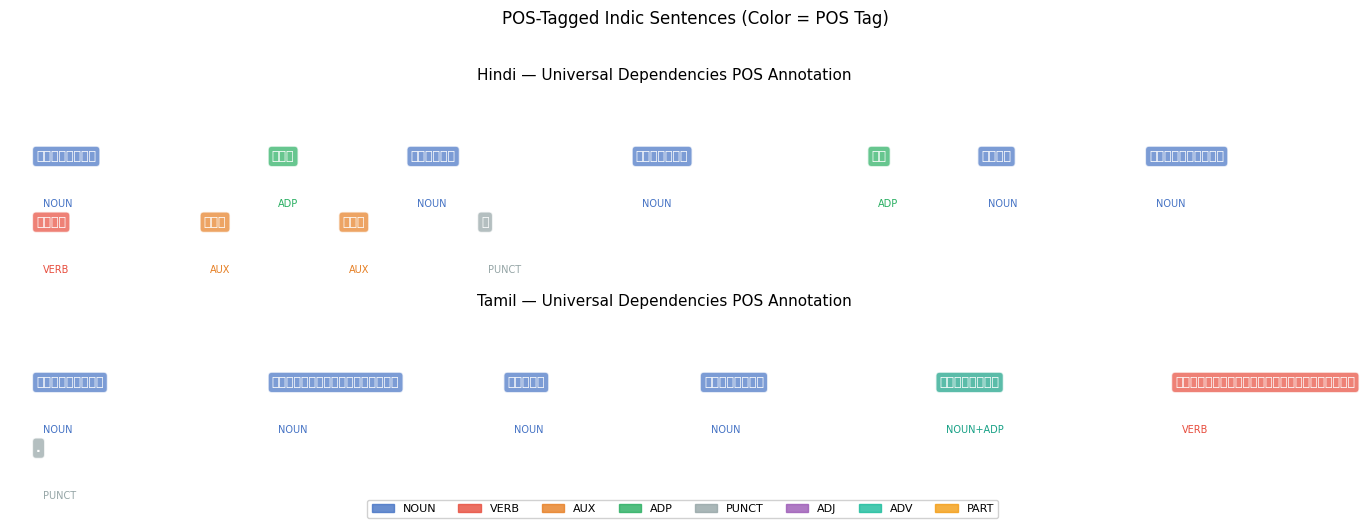

Note: Tamil has fewer tokens but each token is morphologically richer


In [3]:
reset_demo_counters()

# Pre-annotated example for visualization (based on expected Sarvam-M output)
hindi_pos = [
    ('विद्यालय', 'NOUN'), ('में', 'ADP'), ('शिक्षक', 'NOUN'),
    ('छात्रों', 'NOUN'), ('को', 'ADP'), ('भाषा', 'NOUN'),
    ('प्रसंस्करण', 'NOUN'), ('समझा', 'VERB'), ('रहे', 'AUX'), ('हैं', 'AUX'), ('।', 'PUNCT')
]

tamil_pos = [
    ('மாணவர்கள்', 'NOUN'), ('பல்கலைக்கழகத்தின்', 'NOUN'),
    ('கணினி', 'NOUN'), ('அறிவியல்', 'NOUN'), ('துறைக்கு', 'NOUN+ADP'),
    ('வந்துகொண்டிருக்கிறார்கள்', 'VERB'), ('.', 'PUNCT')
]

POS_COLORS = {
    'NOUN': '#4472C4', 'VERB': '#E74C3C', 'AUX': '#E67E22',
    'ADP': '#27AE60', 'PUNCT': '#95A5A6', 'ADJ': '#9B59B6',
    'ADV': '#1ABC9C', 'PART': '#F39C12', 'PROPN': '#2C3E50',
    'NOUN+ADP': '#16A085', 'DET': '#8E44AD', 'CCONJ': '#D35400',
}

def plot_pos_tokens(tokens_tags, lang_name, ax, y=0.5):
    x = 0.02
    for word, tag in tokens_tags:
        color = POS_COLORS.get(tag, '#888888')
        bbox = dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7, edgecolor='white')
        txt = ax.text(x, y+0.15, word, fontsize=9, bbox=bbox, color='white', fontweight='bold',
                      transform=ax.transAxes, va='center')
        ax.text(x + 0.005, y - 0.1, tag, fontsize=7, color=color, transform=ax.transAxes, va='center')
        x += min(len(word)*0.022 + 0.04, 0.18)
        if x > 0.95:
            x = 0.02
            y -= 0.35

fig, axes = plt.subplots(2, 1, figsize=(14, 5))

for ax, (tokens_tags, lang_name) in zip(axes, [(hindi_pos, 'Hindi'), (tamil_pos, 'Tamil')]):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(f'{lang_name} — Universal Dependencies POS Annotation', fontsize=11, pad=8)
    plot_pos_tokens(tokens_tags, lang_name, ax)

# Legend
legend_patches = [mpatches.Patch(color=c, label=tag, alpha=0.8)
                  for tag, c in list(POS_COLORS.items())[:8]]
fig.legend(handles=legend_patches, loc='lower center', ncol=8, fontsize=8, framealpha=0.9)

plt.suptitle('POS-Tagged Indic Sentences (Color = POS Tag)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/03_pos_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print('Note: Tamil has fewer tokens but each token is morphologically richer')

### Free word order: same Hindi sentence in 3 orders → verify via translation

In [4]:
reset_demo_counters()

word_orders = {
    'SOV (canonical)': 'राम ने स्कूल में किताब पढ़ी।',
    'OVS (topicalized)': 'किताब राम ने स्कूल में पढ़ी।',
    'VSO (verb-initial)': 'पढ़ी राम ने स्कूल में किताब।',
}

print('FREE WORD ORDER DEMO — Hindi')
print('All variants should translate to the same English meaning.')
print('='*60)

for order, sentence in word_orders.items():
    try:
        translation = translate(client, sentence, src='hi-IN', tgt='en-IN')
        print(f'\n[{order}]')
        print(f'  Hindi:   {sentence}')
        print(f'  English: {translation}')
    except Exception as e:
        print(f'  Error: {e}')

print()
print('Textbook Implication: Seq2seq models trained only on canonical SOV order')
print('will struggle with scrambled variants at inference time.')
print('Attention mechanisms (transformer attention partially mitigates this.')

FREE WORD ORDER DEMO — Hindi
All variants should translate to the same English meaning.
Estimated cost: INR 0.0560


INFO | HTTP Request: POST https://api.sarvam.ai/translate "HTTP/1.1 200 OK"



[SOV (canonical)]
  Hindi:   राम ने स्कूल में किताब पढ़ी।
  English: Ram read a book at school.
Estimated cost: INR 0.0560


INFO | HTTP Request: POST https://api.sarvam.ai/translate "HTTP/1.1 200 OK"



[OVS (topicalized)]
  Hindi:   किताब राम ने स्कूल में पढ़ी।
  English: The book Ram studied in school.
Estimated cost: INR 0.0560


INFO | HTTP Request: POST https://api.sarvam.ai/translate "HTTP/1.1 200 OK"



[VSO (verb-initial)]
  Hindi:   पढ़ी राम ने स्कूल में किताब।
  English: Read Ram's book in school.

Textbook Implication: Seq2seq models trained only on canonical SOV order
will struggle with scrambled variants at inference time.
Attention mechanisms (transformer attention partially mitigates this.


### Named Entity Recognition on Hindi news passage

In [5]:
reset_demo_counters()

hindi_news = 'प्रधानमंत्री नरेंद्र मोदी ने दिल्ली में भारतीय प्रौद्योगिकी संस्थान के छात्रों को संबोधित किया।'

messages = [
    {'role': 'system', 'content': 'You are an expert NLP system for Hindi Named Entity Recognition.'},
    {'role': 'user', 'content': f'''Perform Named Entity Recognition on this Hindi sentence:
"{hindi_news}"

Identify all named entities with their type (PERSON, LOCATION, ORGANIZATION, DESIGNATION).
Format as: entity [TYPE]
Then give English translation.'''}
]

try:
    result = chat_complete(client, messages)
    if '<think>' in result:
        result = result.split('</think>')[-1].strip()
    print('Hindi NER Results:')
    print(f'Input: {hindi_news}')
    print()
    print(result[:600])
except Exception as e:
    print(f'Error: {e}')

Estimated cost: INR 0.7320


INFO | HTTP Request: POST https://api.sarvam.ai/v1/chat/completions "HTTP/1.1 200 OK"


Hindi NER Results:
Input: प्रधानमंत्री नरेंद्र मोदी ने दिल्ली में भारतीय प्रौद्योगिकी संस्थान के छात्रों को संबोधित किया।

प्रधानमंत्री [DESIGNATION]  
नरेंद्र मोदी [PERSON]  
दिल्ली [LOCATION]  
भारतीय प्रौद्योगिकी संस्थान [ORGANIZATION]  

English Translation:  
Prime Minister Narendra Modi addressed the students of the Indian Institute of Technology in Delhi.


### Code-mixing: POS tag with language label per token

In [6]:
reset_demo_counters()

print(f'Code-mixed input: {CODE_MIXED}')
print()

messages = [
    {'role': 'system', 'content': 'You are an expert in code-mixed Hindi-English NLP.'},
    {'role': 'user', 'content': f'''POS-tag this code-mixed Hindi-English sentence AND label the language of each token (HI=Hindi, EN=English):
"{CODE_MIXED}"

Format: word/POS/LANG for each token.
Then explain which language is the 'matrix language' (the syntactic backbone) according to Myers-Scotton's Matrix Language Frame theory.'''}
]

try:
    result = chat_complete(client, messages)
    if '<think>' in result:
        result = result.split('</think>')[-1].strip()
    print(result[:800])
except Exception as e:
    print(f'Error: {e}')

Code-mixed input: मुझे machine learning बहुत interesting लगती है।

Estimated cost: INR 0.7660


INFO | HTTP Request: POST https://api.sarvam.ai/v1/chat/completions "HTTP/1.1 200 OK"


Here's the POS-tagging and language labeling:

मुझे/PRON/HI  
machine/NN/EN  
learning/NN/EN  
बहुत/JJ/HI  
interesting/JJ/EN  
लगती/VERB/HI  
है/VERB


### Visualization: token-level language detection for code-mixed text

C:\Users\basur\AppData\Local\Temp\ipykernel_32260\2252183113.py:38: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\basur\AppData\Local\Temp\ipykernel_32260\2252183113.py:38: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
C:\Users\basur\AppData\Local\Temp\ipykernel_32260\2252183113.py:38: UserWarning: Glyph 2369 (\N{DEVANAGARI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\basur\AppData\Local\Temp\ipykernel_32260\2252183113.py:38: UserWarning: Glyph 2333 (\N{DEVANAGARI LETTER JHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\basur\AppData\Local\Temp\ipykernel_32260\2252183113.py:38: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\basur\AppData\Local\Temp\ipykernel_32260\2252183113.py:38: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font

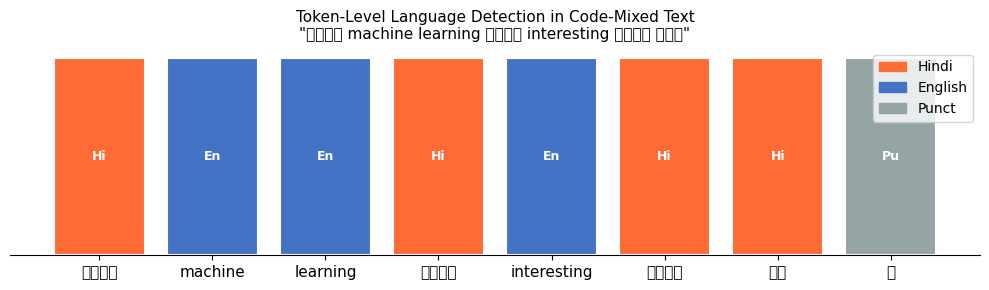

In [7]:
reset_demo_counters()

# Manually annotated code-mixed tokens for visualization
codemix_tokens = [
    ('मुझे', 'Hindi'),
    ('machine', 'English'),
    ('learning', 'English'),
    ('बहुत', 'Hindi'),
    ('interesting', 'English'),
    ('लगती', 'Hindi'),
    ('है', 'Hindi'),
    ('।', 'Punct'),
]

lang_colors_cm = {'Hindi': '#FF6B35', 'English': '#4472C4', 'Punct': '#95A5A6'}
token_words = [t[0] for t in codemix_tokens]
token_langs = [t[1] for t in codemix_tokens]
bar_colors = [lang_colors_cm[l] for l in token_langs]

fig, ax = plt.subplots(figsize=(10, 3))
x = np.arange(len(token_words))
ax.bar(x, [1]*len(token_words), color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(token_words, fontsize=11)
ax.set_yticks([])
ax.set_title(f'Token-Level Language Detection in Code-Mixed Text\n"{CODE_MIXED}"', fontsize=11)

handles = [mpatches.Patch(color=c, label=l) for l, c in lang_colors_cm.items()]
ax.legend(handles=handles, loc='upper right')

# Add language labels inside bars
for i, lang in enumerate(token_langs):
    ax.text(i, 0.5, lang[:2], ha='center', va='center', color='white', fontweight='bold', fontsize=9)

import seaborn as sns
sns.despine(left=True)
plt.tight_layout()
plt.savefig('../outputs/figures/03_codemix_language.png', dpi=120, bbox_inches='tight')
plt.show()

## Key Takeaways (Sequence Labeling & Syntactic Parsing)

1. **POS tagging isn't language-neutral.** Hindi's postpositions, compound verbs, and honorific markers require Indic-specific tagsets. Universal Dependencies helps but doesn't solve everything.

2. **Free word order breaks n-gram models.** HMM and CRF taggers (HMM and CRF taggers (covered in the sequence labeling sections) trained on canonical SOV order assign near-zero probability to scrambled but grammatical variants. Neural models with attention handle scrambling better.

3. **Tamil's agglutination collapses sequence length but inflates morphology.** One Tamil token carries information that 4-6 English tokens would encode. Models need morphological decomposition, not just surface-form tagging.

4. **NER in Indic languages must handle Sanskrit-origin proper nouns.** `नरेंद्र` (Narendra) is also a common noun root (lord of men). Disambiguation requires context — exactly what BERT-style contextual embeddings provide.

5. **Code-mixing follows Matrix Language Frame theory.** In Hindi-English mixing, Hindi is the matrix language (provides grammatical morphemes, SOV structure). English provides content words but slots into Hindi syntax.

**Next:** Notebook 04 — how transformers and attention mechanisms enable neural machine translation for Indic languages.

---
## ⭐ Bonus — Failure Mode: Tamil Sentential Negation & SOV Edge Cases

> **Skip if time is short.** This cell stress-tests Sarvam-M's POS tagger with
> linguistic constructions that are known to confuse models trained primarily on
> Indo-Aryan or European languages.

### Background
The sequence labeling chapter shows that HMM/CRF taggers rely on local
transition probabilities. For Tamil and other Dravidian languages, two
constructions create hard failures:

**1. Sentential negation at the sentence-final position**
Tamil negation is expressed by a negative finite verb *at the end* of the
sentence — the opposite of English ("I do NOT go" vs Tamil "I go NOT-VERB"):
```
அவர் வரமாட்டார்.  = He will-not-come.  (negation fused into final verb)
அவர் வருவார்.     = He will-come.       (positive)
```
A tagger that doesn't see the full sentence before tagging will misclassify the
negative finite verb, breaking downstream sentiment and entailment models.

**2. Null subject (pro-drop)**
Tamil routinely omits the subject when recoverable from context:
```
வந்தான்.  = (He) came.   ← subject is null, encoded in verb morphology
```
English-style dependency parsers expect a subject NP — Tamil has none.


### ⭐ BONUS — Failure mode: Tamil negation and pro-drop for POS tagging

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from utils.sarvam_helpers import load_client, reset_demo_counters, chat_complete, translate

reset_demo_counters()
client = load_client()

test_cases = [
    {
        "label": "Tamil — sentence-final negation",
        "text":  "அவர் நாளை வரமாட்டார்.",
        "note":  "He will not come tomorrow. Negation fused into final verb.",
        "trap":  "Tagger may label வரமாட்டார் as a simple VERB, missing the NEG morpheme.",
    },
    {
        "label": "Tamil — pro-drop (null subject)",
        "text":  "நேற்று வந்தான்.",
        "note":  "Came yesterday. Subject '(he)' is null — encoded in வந்தான் (3rd-masc-sg).",
        "trap":  "Parser expects an overt NP subject and may produce a malformed tree.",
    },
    {
        "label": "Hindi — scrambled + verb-raising",
        "text":  "किताब मैंने पढ़ ली है।",
        "note":  "The book I have read (completive). Object-initial, compound verb.",
        "trap":  "HMM trained on canonical SOV order assigns near-zero probability.",
    },
]

print("FAILURE MODE: Grammatical edge cases for POS/dependency taggers")
print("="*65)

for tc in test_cases:
    print(f"\n[{tc['label']}]")
    print(f"  Input  : {tc['text']}")
    print(f"  Meaning: {tc['note']}")
    print(f"  Trap   : {tc['trap']}")

    # Ask Sarvam-M to POS-tag it
    msg = [
        {"role": "system",
         "content": "You are an expert in Universal Dependencies annotation "
                    "for Indian languages. Be precise about morphological tags."},
        {"role": "user",
         "content": f"POS-tag this sentence using Universal Dependencies tags: "
                    f'\"{tc["text"]}\"\n'
                    "Format: word/TAG. Then note any negation or null-subject phenomena."},
    ]
    try:
        result = chat_complete(client, msg)
        if "<think>" in result:
            result = result.split("</think>")[-1].strip()
        print(f"  Sarvam-M output:\n    {result[:400]}")
    except Exception as e:
        print(f"  Error: {e}")

print("\nTakeaway: Sarvam-M handles these better than classical HMM/CRF taggers")
print("because transformer attention can see the full sentence before assigning")
print("any tag — eliminating the left-to-right Markov assumption of HMMs.")


INFO | SarvamAI client initialised (DEMO_MODE=True)


FAILURE MODE: Grammatical edge cases for POS/dependency taggers

[Tamil — sentence-final negation]
  Input  : அவர் நாளை வரமாட்டார்.
  Meaning: He will not come tomorrow. Negation fused into final verb.
  Trap   : Tagger may label வரமாட்டார் as a simple VERB, missing the NEG morpheme.
Estimated cost: INR 0.5220


INFO | HTTP Request: POST https://api.sarvam.ai/v1/chat/completions "HTTP/1.1 200 OK"


  Sarvam-M output:
    <think>
Okay, let's tackle this Tamil sentence: "அவர் நாளை வரமாட்டார்." I need to POS-tag it using Universal Dependencies (UD) tags. First, I'll break down each word.

The sentence translates to "He won't come tomorrow." Let's start with the first word, "அவர்" (avar). In Tamil, this is a third-person singular pronoun, specifically "he" or "she". In UD, pronouns are tagged as PRON. The gender here 

[Tamil — pro-drop (null subject)]
  Input  : நேற்று வந்தான்.
  Meaning: Came yesterday. Subject '(he)' is null — encoded in வந்தான் (3rd-masc-sg).
  Trap   : Parser expects an overt NP subject and may produce a malformed tree.
Estimated cost: INR 0.5100


INFO | HTTP Request: POST https://api.sarvam.ai/v1/chat/completions "HTTP/1.1 200 OK"


  Sarvam-M output:
    நேற்று/ADV  
வந்தான்/VERB  

**Negation:** None  
**Null-subject:** Yes (The subject "he" is implied by the verb morphology - "வந்தான்

[Hindi — scrambled + verb-raising]
  Input  : किताब मैंने पढ़ ली है।
  Meaning: The book I have read (completive). Object-initial, compound verb.
  Trap   : HMM trained on canonical SOV order assigns near-zero probability.
Estimated cost: INR 0.5240


INFO | HTTP Request: POST https://api.sarvam.ai/v1/chat/completions "HTTP/1.1 200 OK"


  Sarvam-M output:
    <think>
Okay, let's tackle this POS tagging for the Hindi sentence "किताब मैंने पढ़ ली है।" using Universal Dependencies (UD) tags. First, I need to break down each word and determine the correct part-of-speech tags.

Starting with "किताब": This is a noun, specifically a common noun. In UD, nouns are tagged as NOUN. So, "किताब/NOUN".

Next, "मैंने": This is a pronoun. In Hindi, "मैं" (I) with the 

Takeaway: Sarvam-M handles these better than classical HMM/CRF taggers
because transformer attention can see the full sentence before assigning
any tag — eliminating the left-to-right Markov assumption of HMMs.


---
## Krutrim Comparison — POS Tagging: Krutrim-spectre-v2 vs Sarvam-M

> **Requires:** `KRUTRIM_CLOUD_API_KEY` in `.env`

### What We're Testing
Both Sarvam-M and Krutrim-spectre-v2 are large multilingual models fine-tuned
on Indic data. For **sequence labeling via prompting**, the key question is:

1. Does the model consistently apply Universal Dependencies POS tags?
2. Does it correctly identify Indic-specific constructions (postpositions,
   compound verbs, agglutinated tokens)?
3. Does it explain its reasoning when the annotation is ambiguous?

We run the same four sentences through both models and compare outputs side
by side. No fine-tuning — this is zero-shot prompting quality, which reflects
how a student or developer would actually use these APIs.

### Evaluation Criteria
- **Consistency:** Same tag for the same word across runs
- **Indic awareness:** Correct tagging of postpositions (ADP after NOUN in Hindi)
- **Morphological depth:** Does it note compound verb structure (समझा रहे हैं)?
- **Explanation quality:** Does it justify ambiguous tags?


### Krutrim-spectre-v2 vs Sarvam-M: zero-shot POS tagging

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from data.sample_texts import SAMPLE_TEXTS, LANGUAGE_NAMES

try:
    from utils.krutrim_helpers import load_openai_client, krutrim_chat
    from utils.sarvam_helpers import load_client, chat_complete, reset_demo_counters
    import pandas as pd

    reset_demo_counters()
    sarvam  = load_client()
    krutrim = load_openai_client()

    # Test on Hindi and Tamil (most linguistically distinct)
    test_cases = [
        ("hi-IN", SAMPLE_TEXTS["hi-IN"]),
        ("ta-IN", SAMPLE_TEXTS["ta-IN"]),
    ]

    POS_PROMPT = (
        "POS-tag this sentence using Universal Dependencies tags "
        "(NOUN, VERB, AUX, ADP, DET, PRON, ADJ, ADV, PART, PUNCT, NUM, "
        "PROPN, CCONJ, SCONJ). Format: word/TAG for each token. "
        "Then in one sentence note the word order (SOV/SVO/other) "
        "and any postpositions or compound verbs found."

# Sentence: ""
    )

    results_table = []

    for lang, text in test_cases:
        print(f"{'='*65}")
        print(f"Language: {LANGUAGE_NAMES[lang]}")
        print(f"Input:    {text}")
        print()

        prompt_msgs = [
            {"role": "system",
             "content": "You are an expert computational linguist specialising "
                        "in Indian languages and Universal Dependencies annotation."},
            {"role": "user", "content": POS_PROMPT + f'"{text}"'},
        ]

        # Sarvam-M
        try:
            sarvam_out = chat_complete(sarvam, prompt_msgs, reasoning_effort="low")
            if "<think>" in sarvam_out:
                sarvam_out = sarvam_out.split("</think>")[-1].strip()
        except Exception as e:
            sarvam_out = f"[Sarvam error: {e}]"

        # Krutrim-spectre-v2
        try:
            krutrim_out = krutrim_chat(krutrim, prompt_msgs, temperature=0.1)
        except Exception as e:
            krutrim_out = f"[Krutrim error: {e}]"

        print(f"Sarvam-M output:{sarvam_out[:400]}")
        print(f"Krutrim-spectre-v2 output:{krutrim_out[:400]}")

        results_table.append({
            "Language": LANGUAGE_NAMES[lang],
            "Sarvam-M (first 200 chars)":    sarvam_out[:200],
            "Krutrim-spectre-v2 (first 200)": krutrim_out[:200],
        })

    print("--- Qualitative Comparison Notes ---")
    print("Look for these differences:")
    print("  1. Does either model mislabel a postposition (में, को) as NOUN/VERB?")
    print("  2. Does either model split Tamil agglutinated tokens or treat as VERB?")
    print("  3. Which model provides better reasoning about compound verbs?")
    print("  4. Consistency: run again -- do tags change between runs?")

except EnvironmentError as e:
    print(f"Krutrim key not set: {e}")
except Exception as e:
    import traceback; traceback.print_exc()

SyntaxError: unterminated string literal (detected at line 69) (386112746.py, line 69)